# 03 Stage Structure

This notebook renders the stage-removal, dense-vs-staged, and wrapper/order comparisons from three section-local CSVs.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

STAGE_PATH = RESULTS_ROOT / "03_stage_structure/03a_stage_ablation.csv"
DENSE_PATH = RESULTS_ROOT / "03_stage_structure/03b_dense_vs_staged.csv"
WRAPPER_PATH = RESULTS_ROOT / "03_stage_structure/03c_wrapper_order.csv"

STAGE_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "ablation_group", "metric", "cutoff", "value",
    "split", "selection_rule", "run_id", "source_path", "notes",
]
DENSE_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "layout_variant", "stage_count", "metric", "cutoff", "value",
    "split", "selection_rule", "run_id", "source_path", "notes",
]
WRAPPER_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "wrapper_variant", "stage_order", "metric", "cutoff", "value",
    "split", "selection_rule", "run_id", "source_path", "notes",
]


def demo_stage() -> pd.DataFrame:
    rows = []
    values = {"full": 0.1185, "remove_macro": 0.1152, "remove_mid": 0.1144, "remove_micro": 0.1129}
    for group, value in values.items():
        rows.append(
            {
                "paper_section": "03_stage_structure",
                "panel": "stage_ablation",
                "dataset": "KuaiRec",
                "variant_or_model": "RouteRec",
                "ablation_group": group,
                "metric": "MRR",
                "cutoff": 20,
                "value": value,
                "split": "test",
                "selection_rule": "demo",
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            }
        )
    return pd.DataFrame(rows)


def demo_dense() -> pd.DataFrame:
    rows = []
    values = [("dense_ffn", 0, 0.1082), ("single_stage", 1, 0.1126), ("two_stage", 2, 0.1161), ("three_stage", 3, 0.1185)]
    for layout_variant, stage_count, value in values:
        rows.append(
            {
                "paper_section": "03_stage_structure",
                "panel": "dense_vs_staged",
                "dataset": "KuaiRec",
                "variant_or_model": "RouteRec",
                "layout_variant": layout_variant,
                "stage_count": stage_count,
                "metric": "MRR",
                "cutoff": 20,
                "value": value,
                "split": "test",
                "selection_rule": "demo",
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            }
        )
    return pd.DataFrame(rows)


def demo_wrapper() -> pd.DataFrame:
    rows = []
    values = [("A8", "macro-mid-micro", 0.1141), ("A10", "macro-mid-micro", 0.1185), ("A11", "mid-macro-micro", 0.1163), ("A12", "macro-micro-mid", 0.1170)]
    for wrapper_variant, stage_order, value in values:
        rows.append(
            {
                "paper_section": "03_stage_structure",
                "panel": "wrapper_order",
                "dataset": "KuaiRec",
                "variant_or_model": "RouteRec",
                "wrapper_variant": wrapper_variant,
                "stage_order": stage_order,
                "metric": "MRR",
                "cutoff": 20,
                "value": value,
                "split": "test",
                "selection_rule": "demo",
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            }
        )
    return pd.DataFrame(rows)


In [2]:
stage_df, stage_mode = load_csv_or_demo(STAGE_PATH, STAGE_COLUMNS, demo_builder=demo_stage)
dense_df, dense_mode = load_csv_or_demo(DENSE_PATH, DENSE_COLUMNS, demo_builder=demo_dense)
wrapper_df, wrapper_mode = load_csv_or_demo(WRAPPER_PATH, WRAPPER_COLUMNS, demo_builder=demo_wrapper)
display(Markdown(f"**Load mode:** stage={stage_mode}, dense={dense_mode}, wrapper={wrapper_mode}"))
display(stage_df)
display(dense_df)
display(wrapper_df)


**Load mode:** stage=demo, dense=demo, wrapper=demo

,paper_section,panel,dataset,variant_or_model,ablation_group,metric,cutoff,value,split,selection_rule,run_id,source_path,notes
0,03_stage_structure,stage_ablation,KuaiRec,RouteRec,full,MRR,20,0.1185,test,demo,demo,demo,demo data
1,03_stage_structure,stage_ablation,KuaiRec,RouteRec,remove_macro,MRR,20,0.1152,test,demo,demo,demo,demo data
2,03_stage_structure,stage_ablation,KuaiRec,RouteRec,remove_mid,MRR,20,0.1144,test,demo,demo,demo,demo data
3,03_stage_structure,stage_ablation,KuaiRec,RouteRec,remove_micro,MRR,20,0.1129,test,demo,demo,demo,demo data


,paper_section,panel,dataset,variant_or_model,layout_variant,stage_count,metric,cutoff,value,split,selection_rule,run_id,source_path,notes
0,03_stage_structure,dense_vs_staged,KuaiRec,RouteRec,dense_ffn,0,MRR,20,0.1082,test,demo,demo,demo,demo data
1,03_stage_structure,dense_vs_staged,KuaiRec,RouteRec,single_stage,1,MRR,20,0.1126,test,demo,demo,demo,demo data
2,03_stage_structure,dense_vs_staged,KuaiRec,RouteRec,two_stage,2,MRR,20,0.1161,test,demo,demo,demo,demo data
3,03_stage_structure,dense_vs_staged,KuaiRec,RouteRec,three_stage,3,MRR,20,0.1185,test,demo,demo,demo,demo data


,paper_section,panel,dataset,variant_or_model,wrapper_variant,stage_order,metric,cutoff,value,split,selection_rule,run_id,source_path,notes
0,03_stage_structure,wrapper_order,KuaiRec,RouteRec,A8,macro-mid-micro,MRR,20,0.1141,test,demo,demo,demo,demo data
1,03_stage_structure,wrapper_order,KuaiRec,RouteRec,A10,macro-mid-micro,MRR,20,0.1185,test,demo,demo,demo,demo data
2,03_stage_structure,wrapper_order,KuaiRec,RouteRec,A11,mid-macro-micro,MRR,20,0.1163,test,demo,demo,demo,demo data
3,03_stage_structure,wrapper_order,KuaiRec,RouteRec,A12,macro-micro-mid,MRR,20,0.1170,test,demo,demo,demo,demo data


Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/03_stage_structure.png, /workspace/FeaturedMoE/writing/results/generated_figures/03_stage_structure.pdf

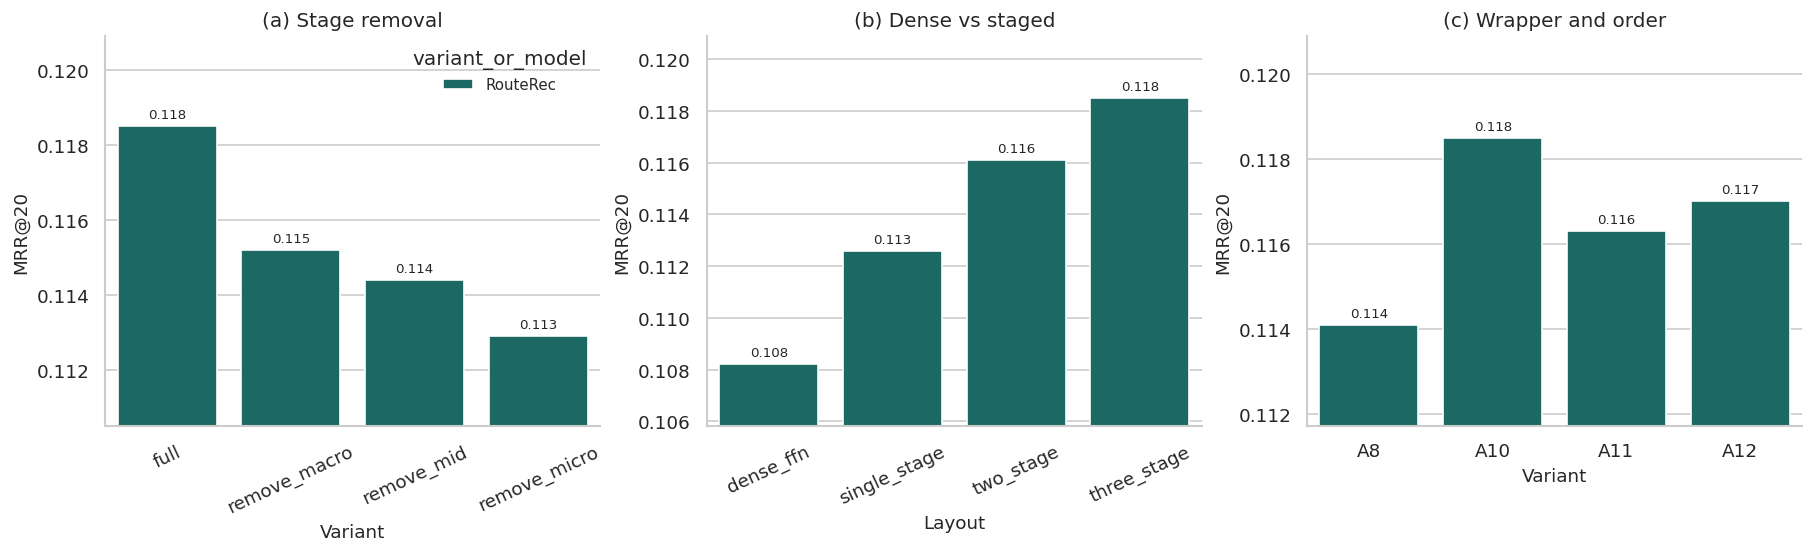

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
grouped_barplot(stage_df, x="ablation_group", hue="variant_or_model", y="value", ax=axes[0], title="(a) Stage removal", ylabel="MRR@20", xlabel="Variant", rotate=25)
grouped_barplot(dense_df, x="layout_variant", hue="variant_or_model", y="value", ax=axes[1], title="(b) Dense vs staged", ylabel="MRR@20", xlabel="Layout", rotate=25)
grouped_barplot(wrapper_df, x="wrapper_variant", hue="variant_or_model", y="value", ax=axes[2], title="(c) Wrapper and order", ylabel="MRR@20", xlabel="Variant", rotate=0)
for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
saved_paths = export_figure(fig, "03_stage_structure", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
